In [1]:
import numpy as np
import rasterio as rio
from rasterio.transform import from_bounds
from rasterio.warp import reproject, Resampling
from pyproj import CRS, Transformer
from rasterio.plot import show
import xarray as xr

In [ ]:
landmask = 

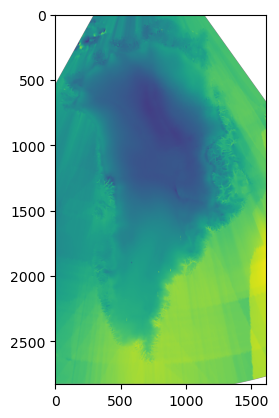

<Axes: >

In [2]:
### REPROJECTION

im_era5_file = "./Data/Test_Gapfilling/t2m_elvcorr_2000_d075.nc"
im_lst_file = "./Data/Test_Gapfilling/GEMLST_MODIS_20000315.tif"

# Load ERA5 data
with xr.open_dataset(im_era5_file) as ds:
    t2m = ds['t2m']
    lat = ds['Y']
    lon = ds['X']
t2m = np.squeeze(t2m.values) - 273.15  # Convert from Kelvin to Celsius    

crs_wgs84 = CRS.from_epsg(4326)  # WGS84
crs_3413 = CRS.from_epsg(3413)   # EPSG:3413
 
transformer = Transformer.from_crs(crs_wgs84, crs_3413, always_xy=True)
x_proj, y_proj = transformer.transform(lon.values, lat.values)

# Ensure ERA5 data match the spatial extent and resolution of the MODIS LST data
with rio.open(im_lst_file) as src:
    lst_data = src.read(1)
    lst_transform = src.transform
    lst_crs = src.crs
    lst_bounds = src.bounds
    lst_width = src.width
    lst_height = src.height

## Create an array to hold the reprojected ERA5 data
reprojected_t2m = np.empty((lst_height, lst_width), dtype=np.float32)

# Reproject the ERA5 data to match the MODIS grid
reproject(
    source=t2m,  # Remove any singleton dimensions
    destination=reprojected_t2m,
    src_transform=from_bounds(x_proj.min(), y_proj.min(), x_proj.max(), y_proj.max(), t2m.shape[1], t2m.shape[0]),
    src_crs=crs_3413,
    dst_transform=lst_transform,
    dst_crs=lst_crs,
    resampling=Resampling.bilinear,
    src_nodata=np.nan,
    dst_nodata=np.nan
)

# write reprojected data to a new GeoTIFF
output_file = "./Data/Test_Gapfilling/era5_2000_d075_reprojected.tif"
with rio.open(output_file, 'w', driver='GTiff', height=lst_height, width=lst_width, count=1, dtype=np.float32, crs=lst_crs, transform=lst_transform) as dst:
    dst.write(reprojected_t2m, 1)

show(reprojected_t2m)